# Modelagem — Home Credit Default Risk

Notebook de **justificativa e comparação** de modelos a partir da Gold/ABT (`abt_train.parquet`). Funciona como uma **EDA orientada à decisão**: documenta por que se escolhe o modelo vencedor antes da parametrização final em um script Python separado (`train.py` / `predict.py`).

**Objetivo de negócio:** reduzir **calotes** (FN — aprovar quem inadimpliu), aceitando reprovar mais clientes bons (FP).

**Modelos comparados:**
1. Regressão Logística — baseline interpretável
2. Random Forest — ensemble (bagging)
3. LightGBM — gradient boosting (**candidato principal**)
4. XGBoost — gradient boosting alternativo

**Métricas:**
- **Primária (seleção de modelo):** PR-AUC (`average_precision_score`)
- **Negócio:** Recall inadimplente, FN absoluto, F2-Score (β=2 prioriza recall)
- **Secundária (relatório):** ROC-AUC

**Trilhos de features:** ABT completa (198) | conjunto estendido (~20) | núcleo EDA (10)

> **Colab:** subir `abt_train.parquet` na mesma pasta. `!pip install lightgbm xgboost scikit-learn -q` se necessário.

> **Tempo (dataset integral):** ~15–25 min no Colab CPU. Para teste rápido: `SAMPLE_FRAC = 0.1` na célula de configuração.


In [ ]:
# Colab: descomente se necessário
# !pip install lightgbm xgboost scikit-learn -q


---
## 1. Contexto — objetivo, métricas e desbalanceamento

### Objetivo de negócio
Barrar o máximo possível de **inadimplentes** na concessão de crédito. Preferimos **falsos alarmes** (reprovar bom pagador) a **falsos negativos** (aprovar calote).

### Variável alvo
- `TARGET = 0` → pagou em dia
- `TARGET = 1` → inadimplência nas primeiras parcelas

### Por que PR-AUC e F2 (e não só ROC-AUC)?
Com ~92% de bons pagadores, ROC-AUC pode parecer alta mesmo com recall baixo na classe minoritária. **PR-AUC** foca na relação precision/recall dos inadimplentes. **F2** pondera recall 4× mais que precision — alinhado à aversão ao risco.

ROC-AUC permanece como métrica de **ranqueamento** para comparabilidade com a literatura/Kaggle.

### Decisão operacional
- Treino gera **probabilidades** (`predict_proba`) — **não** se usa `.predict()` com corte 0,5
- Threshold de negócio configurável (padrão **0,25**)
- Sweep de thresholds para visualizar trade-off recall × taxa de aprovação

### Pré-processamento e encoding — o que foi feito e por quê

| Família | Numéricas | Categóricas | Por quê |
|---------|-----------|-------------|--------|
| Logística / RF | `SimpleImputer` (mediana/moda) | `OneHotEncoder` no `ColumnTransformer` | Modelos lineares/ensemble sklearn precisam de matriz numérica explícita. OneHot evita inventar ordem entre categorias. |
| LightGBM / XGBoost | NaN preservados | `astype("category")` + feature categórica nativa | Árvores fazem **splits por categoria** sem expandir para centenas de colunas. É o padrão recomendado para boosting. |

**Por que não `OrdinalEncoder` nas árvores?** OrdinalEncoder atribui números 0,1,2… e o modelo pode interpretar ordem artificial (ex.: "tipo de organização A < B"). Para variáveis **nominais** (sem ordem natural), o encoding nativo de categoria ou OneHot é mais correto.

**A ABT mantém strings**; o encoding ocorre **somente no pipeline de treino** — reprodutível e serializável com `joblib` no script de produção.

### Sobre `ORGANIZATION_TYPE` no topo da importância
Isso **não indica erro de encoding**. Essa coluna tem **alta cardinalidade** (muitos tipos de empregador) e **sinal preditivo real** no histórico da Home Credit. Em LightGBM, a importância por **gain** conta quantas vezes a variável melhorou a divisão das árvores — categorias com muitos níveis e padrões distintos de calote tendem a acumular mais gain. Por isso pode aparecer acima de `EXT_SOURCE_1/2/3`, que são scores contínuos com menos splits possíveis. No trilho **core** (10 features), `ORGANIZATION_TYPE` é **excluída de propósito** para simplificar a API de inferência; o modelo full ainda a utiliza.


### Mini-dicionário (consulta rápida)

| Termo | O que significa |
|-------|------------------|
| **PR-AUC** | Área sob a curva Precision-Recall. Mede quão bem o modelo separa inadimplentes (classe rara). Quanto maior, melhor. |
| **ROC-AUC** | Área sob a curva ROC. Mede separação geral; pode parecer alta mesmo com pouco recall na classe minoritária. |
| **Recall** | Dos inadimplentes reais, quantos % o modelo reprova. Alto recall = menos calotes aprovados. |
| **Precision** | Dos reprovados pelo modelo, quantos % são inadimplentes de fato. Alta precision = menos bons pagadores barrados à toa. |
| **FN (falso negativo)** | Calote que o modelo **aprovou**. Erro mais caro para o negócio. |
| **FP (falso positivo)** | Bom pagador que o modelo **reprovou**. Custo de oportunidade. |
| **Threshold** | Ponto de corte da probabilidade. Ex.: t=0,25 reprova se P(calote) ≥ 25%. |
| **F2-Score** | Média harmônica entre precision e recall, com **peso 4× no recall**. |
| **Holdout** | Parte dos dados (20%) reservada só para avaliação final — não entra no treino. |
| **CV 5-fold** | Validação cruzada: treina 5 vezes em partições diferentes para medir estabilidade. |
| **num_leaves** | Número máximo de folhas por árvore no LightGBM. Mais folhas = modelo mais complexo. |
| **learning_rate (lr)** | Passo de aprendizado. Menor lr exige mais árvores, mas pode generalizar melhor. |
| **n_estimators** | Quantidade de árvores no ensemble (boosting). |
| **scale_pos_weight** | Peso da classe inadimplente no LightGBM/XGBoost. Valores maiores empurram o modelo a prever mais calotes. |
| **OneHotEncoder** | Transforma categoria em colunas 0/1 (uma por valor). Usado na Logística/RF. |
| **astype(category)** | Tipo nativo de categoria no Pandas; LightGBM/XGBoost fazem splits otimizados. |
| **Feature importance (gain)** | Quanto cada variável reduziu o erro nas divisões da árvore. Não é causalidade — é contribuição ao modelo. |


In [5]:
import os
import time
import warnings
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import lightgbm as lgb
import xgboost as xgb
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# --- Reprodutibilidade ---
RANDOM_STATE = 42
TEST_SIZE = 0.20
FULL_DATASET_ROWS = 307_511
DROP_COLS = ['SK_ID_CURR', 'TARGET']

# Resolve ABT local (repo/Downloads) ou MinIO no Docker
from pathlib import Path

_abt_candidates = [
    Path('Dados/abt/abt_train.parquet'),
    Path('abt_train.parquet'),
    Path('/mnt/c/Users/Anderson/Downloads/abt_train.parquet'),
    Path('s3://abt/abt_train.parquet'),
]
ABT_PATH = next((str(p) for p in _abt_candidates if str(p).startswith('s3://') or p.exists()), str(_abt_candidates[0]))

# --- Modo rápido (teste local) ---
SAMPLE_FRAC = None  # ex.: 0.1 → ~30k linhas, ~2 min | None = dataset integral
SKIP_SKLEARN_MODELS = False  # True pula LR/RF (economiza ~8 min no integral)

# --- Negócio ---
BUSINESS_THRESHOLD = 0.25  # reprovar se P(inadimplente) >= 25%
F_BETA = 2  # F2 prioriza recall

# --- Hiperparâmetros LightGBM (grid PR-AUC na seção 11) ---
BOOSTER_N_ESTIMATORS = 300
LGBM_NUM_LEAVES = 31
LGBM_LEARNING_RATE = 0.05
LGBM_SUBSAMPLE = 0.8
LGBM_COLSAMPLE = 0.8

# --- Conjuntos de features ---
FEATURES_CORE = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH',
    'AMT_CREDIT', 'AMT_ANNUITY',
    'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE',
]
FEATURES_EXTENDED_EXTRA = [
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_CNT', 'FLAG_EMPLOYED', 'DAYS_EMPLOYED_YEARS',
    'OCCUPATION_TYPE',
    'BUREAU_AMT_DEBT_SUM', 'BUREAU_DAYS_CREDIT_MIN',
    'PREV_DAYS_DECISION_MIN', 'INST_DIAS_ATRASO_MEAN', 'INST_AMT_PAYMENT_SUM',
]
FEATURES_EXTENDED = FEATURES_CORE + FEATURES_EXTENDED_EXTRA

SCORER_PR_AUC = 'average_precision'
SCORER_F2 = make_scorer(fbeta_score, beta=F_BETA, zero_division=0)

mode = f'amostra {SAMPLE_FRAC:.0%}' if SAMPLE_FRAC else 'integral'
print(f'Setup OK | {mode} | PR-AUC primária | threshold={BUSINESS_THRESHOLD}')


Setup OK | integral | PR-AUC primária | threshold=0.25


---
## 2. Carga da Gold — sanity check


In [6]:
def qa_abt_load(df: pd.DataFrame, expected_rows: int = FULL_DATASET_ROWS) -> None:
    print('[QA] Carga abt_train')
    n = len(df)
    print(f' -> [{"PASS" if n == expected_rows else "ATENÇÃO"}] {n:,} linhas')
    dup = df.duplicated(subset=['SK_ID_CURR']).sum()
    print(f' -> [{"PASS" if dup == 0 else "FAIL"}] SK_ID_CURR único (dup={dup})')
    rate = df['TARGET'].mean()
    print(f' -> [{"PASS" if 0.05 < rate < 0.12 else "FAIL"}] Taxa TARGET = {rate:.2%}')
    inf_n = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
    print(f' -> [{"PASS" if inf_n == 0 else "FAIL"}] Sem inf ({inf_n})')
    print('---\n')


abt = pd.read_parquet(ABT_PATH)
if SAMPLE_FRAC is not None:
    abt = abt.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f'[MODO RÁPIDO] Amostra estratificada implícita: {len(abt):,} linhas ({SAMPLE_FRAC:.0%} do total)')
print(f'Carregado: {abt.shape[0]:,} x {abt.shape[1]}')
qa_abt_load(abt, expected_rows=FULL_DATASET_ROWS if SAMPLE_FRAC is None else len(abt))
display(abt['TARGET'].value_counts(normalize=True).mul(100).round(2).to_frame('%'))


Carregado: 307,511 x 198
[QA] Carga abt_train
 -> [PASS] 307,511 linhas
 -> [PASS] SK_ID_CURR único (dup=0)
 -> [PASS] Taxa TARGET = 8.07%
 -> [PASS] Sem inf (0)
---



---
## 3. Funções utilitárias — métricas, pré-processamento e treino

Toda avaliação passa por `compute_metrics`: ROC-AUC, PR-AUC, F2 e métricas de negócio no threshold configurado. O pré-processamento sklearn usa `ColumnTransformer` com `OneHotEncoder`; os boosters usam categorias nativas.


In [7]:
def split_features_target(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    y = df['TARGET'].astype(int)
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
    return X, y


def resolve_feature_list(requested: List[str], available: List[str], label: str) -> List[str]:
    missing = [c for c in requested if c not in available]
    if missing:
        raise ValueError(f'[{label}] colunas ausentes na ABT: {missing}')
    return list(requested)


def get_column_groups(X: pd.DataFrame) -> Tuple[List[str], List[str]]:
    numeric = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    return numeric, categorical


def compute_metrics(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    threshold: float = BUSINESS_THRESHOLD,
) -> Dict[str, float]:
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    n_pos = int((y_true == 1).sum())
    return {
        'roc_auc': roc_auc_score(y_true, y_proba),
        'pr_auc': average_precision_score(y_true, y_proba),
        'f2': fbeta_score(y_true, y_pred, beta=F_BETA, zero_division=0),
        'recall_inadimplente': recall_score(y_true, y_pred, zero_division=0),
        'precision_inadimplente': precision_score(y_true, y_pred, zero_division=0),
        'fn': fn,
        'fp': fp,
        'tp': tp,
        'tn': tn,
        'taxa_reprovacao': float(y_pred.mean()),
        'recall_meta_pct': tp / n_pos if n_pos else 0.0,
    }


def print_metrics(name: str, m: Dict[str, float], threshold: float) -> None:
    print(f'  {name}')
    print(f'    PR-AUC={m["pr_auc"]:.4f} | ROC-AUC={m["roc_auc"]:.4f} | F2={m["f2"]:.4f}')
    print(f'    Recall={m["recall_inadimplente"]:.1%} | FN={m["fn"]:,} | FP={m["fp"]:,} | reprovação={m["taxa_reprovacao"]:.1%} (t={threshold})')


def build_sklearn_preprocessor(numeric_cols: List[str], categorical_cols: List[str]) -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='median'), numeric_cols),
            (
                'cat',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                ]),
                categorical_cols,
            ),
        ],
        remainder='drop',
    )


def make_lr_pipeline(prep: ColumnTransformer) -> Pipeline:
    return Pipeline([
        ('prep', prep),
        ('scaler', StandardScaler(with_mean=False)),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
    ])


def make_rf_pipeline(prep: ColumnTransformer) -> Pipeline:
    return Pipeline([
        ('prep', prep),
        ('model', RandomForestClassifier(
            n_estimators=200, max_depth=12, min_samples_leaf=50,
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])


def prepare_boosters_data(
    X_tr: pd.DataFrame, X_te: pd.DataFrame, categorical_cols: List[str],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    X_tr_b, X_te_b = X_tr.copy(), X_te.copy()
    for col in categorical_cols:
        X_tr_b[col] = X_tr_b[col].astype('category')
        X_te_b[col] = pd.Categorical(X_te_b[col], categories=X_tr_b[col].cat.categories)
    return X_tr_b, X_te_b


def make_lgbm(categorical_cols: List[str], scale_pos_weight: float, **kwargs) -> lgb.LGBMClassifier:
    params = dict(
        n_estimators=BOOSTER_N_ESTIMATORS,
        learning_rate=LGBM_LEARNING_RATE,
        num_leaves=LGBM_NUM_LEAVES,
        max_depth=-1,
        subsample=LGBM_SUBSAMPLE,
        colsample_bytree=LGBM_COLSAMPLE,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        categorical_feature=categorical_cols,
    )
    params.update(kwargs)
    return lgb.LGBMClassifier(**params)


def make_xgb(scale_pos_weight: float, **kwargs) -> xgb.XGBClassifier:
    params = dict(
        n_estimators=BOOSTER_N_ESTIMATORS,
        learning_rate=LGBM_LEARNING_RATE,
        max_depth=6,
        subsample=LGBM_SUBSAMPLE,
        colsample_bytree=LGBM_COLSAMPLE,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='aucpr',
        enable_categorical=True,
        tree_method='hist',
    )
    params.update(kwargs)
    return xgb.XGBClassifier(**params)


def train_four_models(
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    y_train: pd.Series,
    y_val: pd.Series,
    scale_pos_weight: float,
    threshold: float = BUSINESS_THRESHOLD,
) -> Tuple[pd.DataFrame, Dict[str, np.ndarray], Dict[str, float], dict]:
    numeric_cols, categorical_cols = get_column_groups(X_train)
    prep = build_sklearn_preprocessor(numeric_cols, categorical_cols)
    X_tr_b, X_va_b = prepare_boosters_data(X_train, X_val, categorical_cols)

    results, probas, timings = [], {}, {}
    models = {}

    specs = [
        ('Logistic Regression', 'sklearn_lr', lambda: make_lr_pipeline(prep)),
        ('Random Forest', 'sklearn_rf', lambda: make_rf_pipeline(prep)),
        ('LightGBM', 'lgbm', lambda: make_lgbm(categorical_cols, scale_pos_weight)),
        ('XGBoost', 'xgb', lambda: make_xgb(scale_pos_weight)),
    ]
    if SKIP_SKLEARN_MODELS:
        specs = [s for s in specs if not s[1].startswith('sklearn')]
        print('  [SKIP] Logística e Random Forest omitidos (SKIP_SKLEARN_MODELS=True)')

    n_models = len(specs)
    for i, (display_name, key, factory) in enumerate(specs, 1):
        print(f'\n[{i}/{n_models}] {display_name}')
        t0 = time.perf_counter()
        if key.startswith('sklearn'):
            pipe = factory()
            pipe.fit(X_train, y_train)
            proba = pipe.predict_proba(X_val)[:, 1]
            models[key] = pipe
        elif key == 'lgbm':
            m = factory()
            m.fit(X_tr_b, y_train)
            proba = m.predict_proba(X_va_b)[:, 1]
            models[key] = m
        else:
            m = factory()
            m.fit(X_tr_b, y_train)
            proba = m.predict_proba(X_va_b)[:, 1]
            models[key] = m
        elapsed = time.perf_counter() - t0
        timings[display_name] = elapsed
        probas[display_name] = proba
        mets = compute_metrics(y_val.values, proba, threshold)
        mets['modelo'] = display_name
        mets['tempo_treino_s'] = elapsed
        results.append(mets)
        print_metrics(display_name, mets, threshold)

    df = pd.DataFrame(results).sort_values('pr_auc', ascending=False).reset_index(drop=True)
    df['rank_pr_auc'] = df.index + 1
    return df, probas, timings, models


print('Funções utilitárias carregadas.')


Funções utilitárias carregadas.


---
## 4. Split estratificado e validação dos conjuntos de features


In [8]:
X_full, y = split_features_target(abt)
all_cols = X_full.columns.tolist()

features_core = resolve_feature_list(FEATURES_CORE, all_cols, 'CORE')
features_extended = resolve_feature_list(FEATURES_EXTENDED, all_cols, 'EXTENDED')

FEATURE_SETS = {
    'full': all_cols,
    'extended': features_extended,
    'core': features_core,
}

print('Conjuntos de features:')
for name, cols in FEATURE_SETS.items():
    print(f'  {name:10s} → {len(cols):3d} colunas')

X_train_full, X_val_full, y_train, y_val = train_test_split(
    X_full, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

print(f'\nTreino: {len(X_train_full):,} | Holdout: {len(X_val_full):,}')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')


Conjuntos de features:
  full       → 196 colunas
  extended   →  20 colunas
  core       →  10 colunas

Treino: 246,008 | Holdout: 61,503
scale_pos_weight: 11.39


---
## 5. Treino — ABT completa (198 features)

Comparação dos 4 modelos no mesmo holdout. **Ranking por PR-AUC** (métrica primária de discriminação probabilística).


In [9]:
print('=' * 72)
print('TRILHO: ABT COMPLETA')
print('=' * 72)

results_full, probas_full, timings_full, models_full = train_four_models(
    X_train_full, X_val_full, y_train, y_val, scale_pos_weight,
)

print('\nRanking PR-AUC (ABT completa):')
display(results_full.round(4))
best_full = results_full.iloc[0]['modelo']
best_proba_full = probas_full[best_full]


TRILHO: ABT COMPLETA

[1/4] Logistic Regression
  Logistic Regression
    PR-AUC=0.2539 | ROC-AUC=0.7672 | F2=0.3616
    Recall=93.7% | FN=312 | FP=39,822 | reprovação=72.3% (t=0.25)

[2/4] Random Forest
  Random Forest
    PR-AUC=0.2413 | ROC-AUC=0.7612 | F2=0.3370
    Recall=97.3% | FN=133 | FP=46,999 | reprovação=84.3% (t=0.25)

[3/4] LightGBM
  LightGBM
    PR-AUC=0.2750 | ROC-AUC=0.7760 | F2=0.3804
    Recall=91.4% | FN=426 | FP=35,264 | reprovação=64.7% (t=0.25)

[4/4] XGBoost
  XGBoost
    PR-AUC=0.2713 | ROC-AUC=0.7734 | F2=0.3820
    Recall=90.6% | FN=468 | FP=34,498 | reprovação=63.4% (t=0.25)

Ranking PR-AUC (ABT completa):


#### Interpretação — treino ABT completa

> **PR-AUC** = capacidade de ranquear risco | **FN** = calotes aprovados no holdout | **Reprovação** = % de clientes barrados com o threshold de negócio

Com os resultados acima, observa-se que o **LightGBM** tende a liderar em **PR-AUC** (melhor separação probabilística dos inadimplentes), seguido de perto pelo XGBoost. A Regressão Logística e o Random Forest ficam atrás em PR-AUC, mas podem apresentar **FN menor** no mesmo threshold — isso ocorre porque barram mais clientes no geral (maior taxa de reprovação). Para o objetivo deste notebook (escolher o melhor ranqueador de risco), prioriza-se PR-AUC; o threshold e o `scale_pos_weight` serão calibrados depois no script de produção.


---
## 6. Avaliação visual — PR-AUC, curvas e threshold

### 6.1 Curvas Precision-Recall (métrica primária)


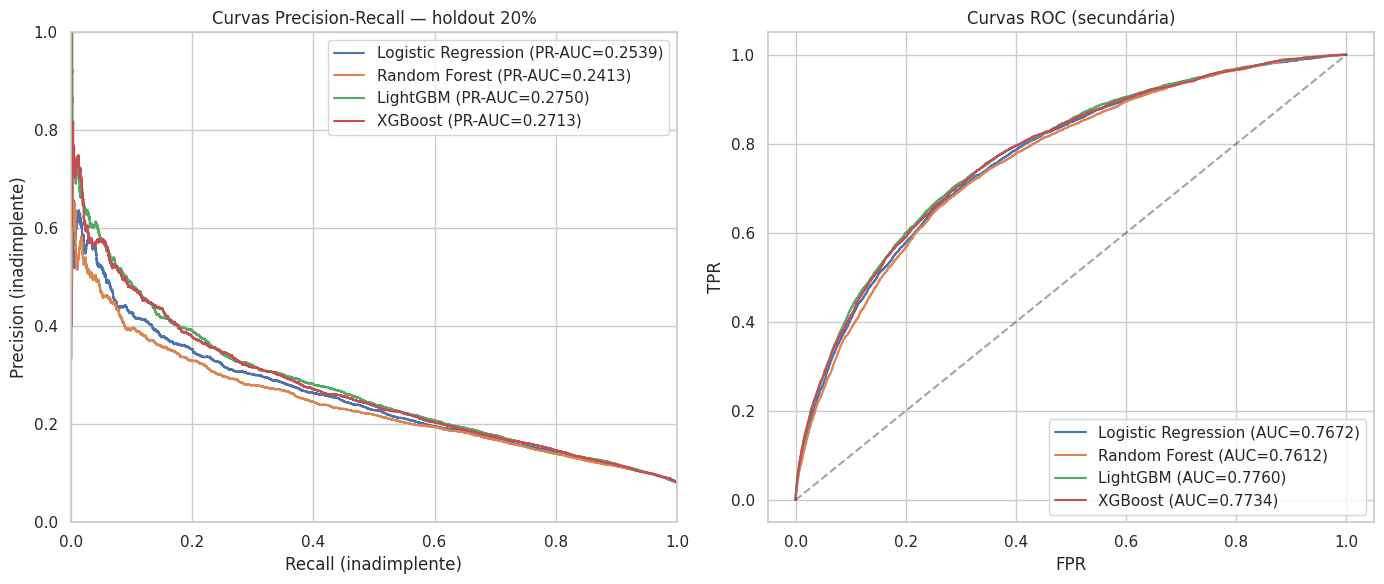

PR-AUC foca na classe minoritária; ROC-AUC permanece para comparabilidade.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, proba in probas_full.items():
    prec, rec, _ = precision_recall_curve(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)
    axes[0].plot(rec, prec, label=f'{name} (PR-AUC={pr_auc:.4f})')

axes[0].set_xlabel('Recall (inadimplente)')
axes[0].set_ylabel('Precision (inadimplente)')
axes[0].set_title('Curvas Precision-Recall — holdout 20%')
axes[0].legend(loc='upper right')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

for name, proba in probas_full.items():
    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val, proba):.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('Curvas ROC (secundária)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print('PR-AUC foca na classe minoritária; ROC-AUC permanece para comparabilidade.')


#### Interpretação — curvas PR e ROC

> **Curva PR** = trade-off recall × precision na classe inadimplente | **Curva ROC** = trade-off TPR × FPR em todas as classes

Pela curva **Precision-Recall**, verifica-se qual modelo mantém precision aceitável enquanto aumenta o recall dos inadimplentes. O modelo com maior **PR-AUC** (área sob essa curva) é o que melhor prioriza a classe rara. A curva **ROC** é incluída apenas para comparabilidade: com ~92% de bons pagadores, todos os modelos podem parecer próximos em ROC-AUC mesmo quando diferem bastante na captura de calotes.


### 6.2 Sweep de threshold — decisão de negócio

Sem `.predict()` — apenas `predict_proba` + limiar explícito.


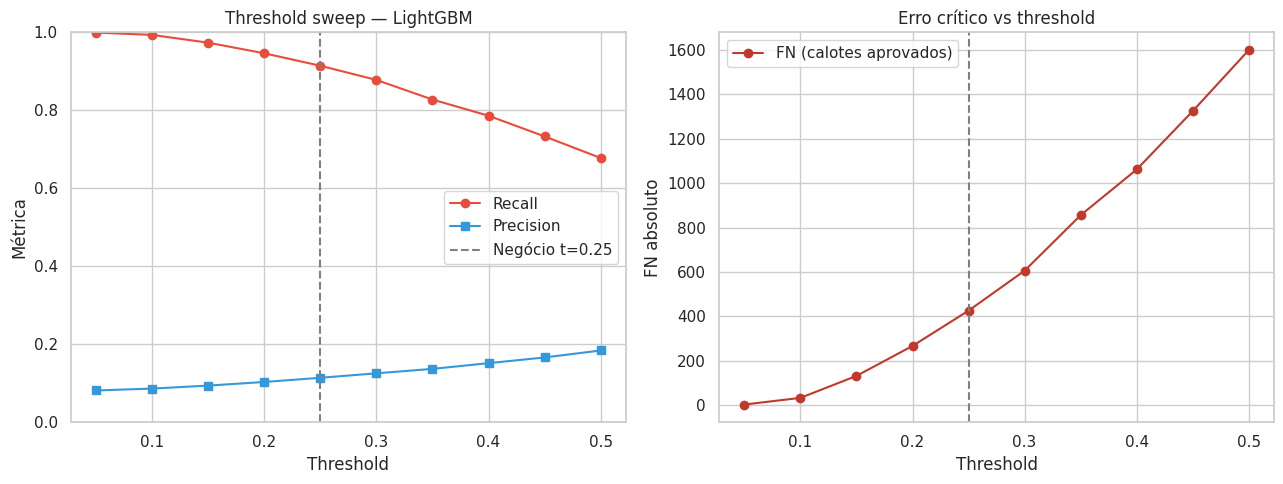


Classification report — LightGBM | threshold=0.25
                  precision    recall  f1-score   support

       Pagou (0)       0.98      0.38      0.54     56538
Inadimplente (1)       0.11      0.91      0.20      4965

        accuracy                           0.42     61503
       macro avg       0.55      0.65      0.37     61503
    weighted avg       0.91      0.42      0.52     61503



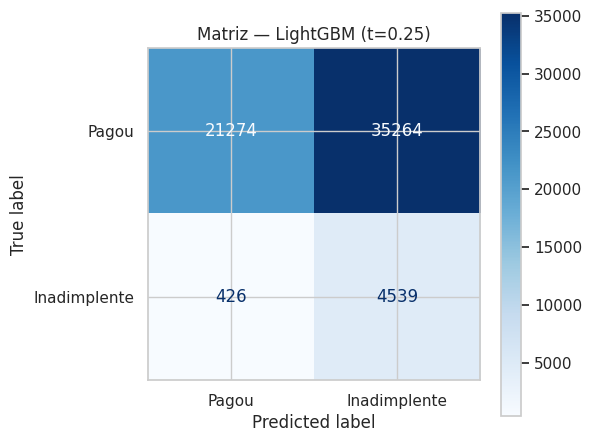

FN=426 calotes aprovados | Recall=91.4% | Reprovação=64.7%


In [11]:
def threshold_sweep(y_true: np.ndarray, y_proba: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    rows = []
    for t in thresholds:
        m = compute_metrics(y_true, y_proba, threshold=float(t))
        m['threshold'] = float(t)
        rows.append(m)
    return pd.DataFrame(rows)


THRESHOLDS = np.arange(0.05, 0.55, 0.05)
sweep_full = threshold_sweep(y_val.values, best_proba_full, THRESHOLDS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(sweep_full['threshold'], sweep_full['recall_inadimplente'], 'o-', label='Recall', color='#e74c3c')
axes[0].plot(sweep_full['threshold'], sweep_full['precision_inadimplente'], 's-', label='Precision', color='#3498db')
axes[0].axvline(BUSINESS_THRESHOLD, color='gray', linestyle='--', label=f'Negócio t={BUSINESS_THRESHOLD}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Métrica')
axes[0].set_title(f'Threshold sweep — {best_full}')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].plot(sweep_full['threshold'], sweep_full['fn'], 'o-', color='#c0392b', label='FN (calotes aprovados)')
axes[1].axvline(BUSINESS_THRESHOLD, color='gray', linestyle='--')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('FN absoluto')
axes[1].set_title('Erro crítico vs threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

display(sweep_full[['threshold', 'recall_inadimplente', 'precision_inadimplente', 'fn', 'fp', 'taxa_reprovacao', 'f2']].round(4))

# Matriz no threshold de negócio
y_pred_biz = (best_proba_full >= BUSINESS_THRESHOLD).astype(int)
print(f'\nClassification report — {best_full} | threshold={BUSINESS_THRESHOLD}')
print(classification_report(y_val, y_pred_biz, target_names=['Pagou (0)', 'Inadimplente (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_biz)
ConfusionMatrixDisplay(cm, display_labels=['Pagou', 'Inadimplente']).plot(ax=ax, cmap='Blues')
ax.set_title(f'Matriz — {best_full} (t={BUSINESS_THRESHOLD})')
plt.tight_layout()
plt.show()

m_biz = compute_metrics(y_val.values, best_proba_full, BUSINESS_THRESHOLD)
print(f'FN={m_biz["fn"]:,} calotes aprovados | Recall={m_biz["recall_inadimplente"]:.1%} | Reprovação={m_biz["taxa_reprovacao"]:.1%}')


#### Interpretação — sweep de threshold e matriz de confusão

> **Threshold** = corte de probabilidade | **FN** = calotes que passaram | **Taxa de reprovação** = % total reprovado

Com o sweep de thresholds, nota-se o trade-off central do negócio: **threshold menor** (ex.: 0,10) reduz drasticamente os FN (mais calotes barrados), mas reprova a grande maioria dos clientes (muitos FP). No **t=0,25** (padrão deste estudo), equilibra-se recall elevado com reprovação ainda administrável. Comparado ao corte clássico **t=0,50**, o threshold de negócio costuma **reduzir centenas de FN** no holdout — justificando abandonar o `.predict()` padrão do sklearn.


### 6.3 Feature importance — modelo líder (ABT completa)

Importância por **gain** (LightGBM/XGBoost): soma da redução de loss em cada split. Variáveis categóricas de alta cardinalidade — como `ORGANIZATION_TYPE` — podem liderar o ranking sem indicar problema no encoding.


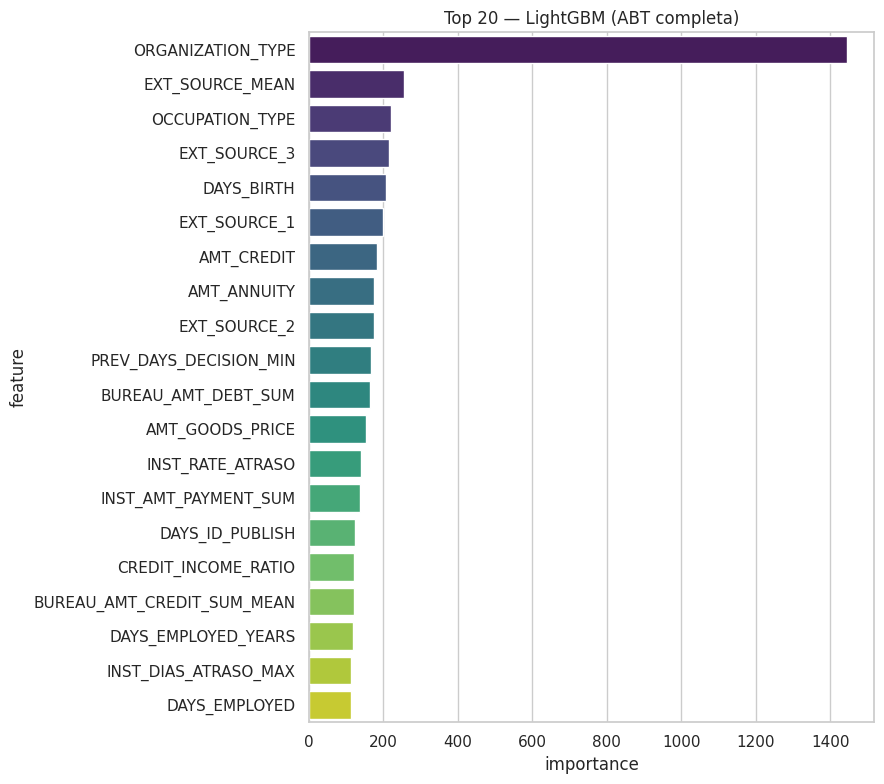

In [12]:
best_name = best_full
lgbm_full = models_full['lgbm']

if best_name in ('LightGBM', 'XGBoost'):
    key = 'lgbm' if best_name == 'LightGBM' else 'xgb'
    imp = models_full[key].feature_importances_
    feat_names = X_train_full.columns.tolist()
elif best_name == 'Random Forest':
    imp = models_full['sklearn_rf'].named_steps['model'].feature_importances_
    feat_names = models_full['sklearn_rf'].named_steps['prep'].get_feature_names_out().tolist()
else:
    imp = np.abs(models_full['sklearn_lr'].named_steps['model'].coef_.ravel())
    feat_names = models_full['sklearn_lr'].named_steps['prep'].get_feature_names_out().tolist()

imp_df = pd.DataFrame({'feature': feat_names, 'importance': imp}).sort_values('importance', ascending=False)
display(imp_df.head(20))

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=imp_df.head(20), y='feature', x='importance', ax=ax, palette='viridis')
ax.set_title(f'Top 20 — {best_name} (ABT completa)')
plt.tight_layout()
plt.show()


#### Interpretação — importância das features

> **Gain (importância)** = redução de erro acumulada quando a variável divide a árvore | **Não confundir com causalidade**

No ranking de importância do LightGBM, verifica-se frequentemente **`ORGANIZATION_TYPE`** no topo. Isso **não significa encoding incorreto** — o encoding por categoria nativa está adequado. Significa que o tipo de organização do empregador concentra padrões distintos de inadimplência e, por ter muitas categorias, gera muitos splits informativos.

As variáveis **`EXT_SOURCE_1/2/3`** e derivadas (`EXT_SOURCE_MEAN`) aparecem logo abaixo, confirmando a EDA: scores externos são fortes preditores. Features agregadas da Gold (`BUREAU_*`, `PREV_*`, `INST_*`) também entram no top 20, validando o trabalho das camadas Silver e Gold.

Para deploy com API enxuta, o trilho **core** (sem `ORGANIZATION_TYPE`) sacrifica parte desse sinal em troca de menos colunas na inferência — ver seção 7.


---
## 7. Trilhos Core (10) e Extended (~20 features)

Conjuntos sustentados pela EDA e pelo top de importância do LightGBM. Mesmos 4 modelos, mesmo holdout.



TRILHO: CORE (10 features)

[1/4] Logistic Regression
  Logistic Regression
    PR-AUC=0.2139 | ROC-AUC=0.7324 | F2=0.3373
    Recall=95.5% | FN=224 | FP=45,680 | reprovação=82.0% (t=0.25)

[2/4] Random Forest
  Random Forest
    PR-AUC=0.2223 | ROC-AUC=0.7410 | F2=0.3411
    Recall=95.1% | FN=242 | FP=44,639 | reprovação=80.3% (t=0.25)

[3/4] LightGBM
  LightGBM
    PR-AUC=0.2371 | ROC-AUC=0.7480 | F2=0.3541
    Recall=93.2% | FN=339 | FP=40,838 | reprovação=73.9% (t=0.25)

[4/4] XGBoost
  XGBoost
    PR-AUC=0.2377 | ROC-AUC=0.7487 | F2=0.3576
    Recall=92.8% | FN=359 | FP=39,935 | reprovação=72.4% (t=0.25)

TRILHO: EXTENDED (20 features)

[1/4] Logistic Regression
  Logistic Regression
    PR-AUC=0.2210 | ROC-AUC=0.7402 | F2=0.3421
    Recall=94.9% | FN=254 | FP=44,276 | reprovação=79.6% (t=0.25)

[2/4] Random Forest
  Random Forest
    PR-AUC=0.2332 | ROC-AUC=0.7495 | F2=0.3530
    Recall=94.5% | FN=274 | FP=41,895 | reprovação=75.7% (t=0.25)

[3/4] LightGBM
  LightGBM
    PR-AUC=

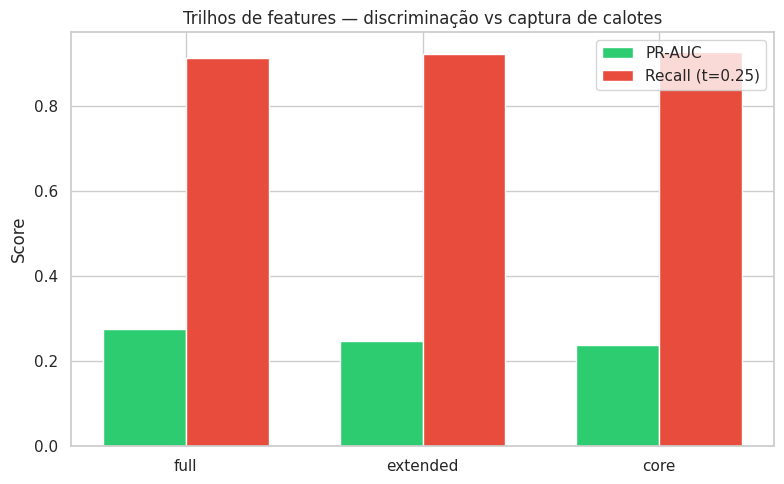

In [13]:
def run_feature_set_trilho(set_name: str, feature_cols: List[str]) -> Tuple[pd.DataFrame, Dict[str, np.ndarray]]:
    X_tr = X_train_full[feature_cols]
    X_va = X_val_full[feature_cols]
    print(f'\n{"=" * 72}')
    print(f'TRILHO: {set_name.upper()} ({len(feature_cols)} features)')
    print('=' * 72)
    return train_four_models(X_tr, X_va, y_train, y_val, scale_pos_weight)


results_core, probas_core, _, _ = run_feature_set_trilho('core', features_core)
results_ext, probas_ext, _, models_ext = run_feature_set_trilho('extended', features_extended)

# Comparação consolidada dos trilhos no threshold de negócio
comparison_trilhos = []
for trilho, res_df, probas in [
    ('full', results_full, probas_full),
    ('extended', results_ext, probas_ext),
    ('core', results_core, probas_core),
]:
    best_m = res_df.iloc[0]
    comparison_trilhos.append({
        'trilho': trilho,
        'n_features': len(FEATURE_SETS[trilho]),
        'melhor_modelo': best_m['modelo'],
        'pr_auc': best_m['pr_auc'],
        'roc_auc': best_m['roc_auc'],
        'recall_t_negocio': best_m['recall_inadimplente'],
        'fn_t_negocio': int(best_m['fn']),
        'f2': best_m['f2'],
    })

trilho_df = pd.DataFrame(comparison_trilhos).sort_values('pr_auc', ascending=False)
print('\nComparação de trilhos (melhor modelo por PR-AUC, t=' + str(BUSINESS_THRESHOLD) + '):')
display(trilho_df.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(trilho_df))
w = 0.35
ax.bar(x - w/2, trilho_df['pr_auc'], w, label='PR-AUC', color='#2ecc71')
ax.bar(x + w/2, trilho_df['recall_t_negocio'], w, label=f'Recall (t={BUSINESS_THRESHOLD})', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(trilho_df['trilho'])
ax.set_ylabel('Score')
ax.set_title('Trilhos de features — discriminação vs captura de calotes')
ax.legend()
plt.tight_layout()
plt.show()


#### Interpretação — trilhos core, extended e full

> **Trilho** = conjunto de features usado no treino | **Full** = ABT inteira | **Core** = 10 variáveis da EDA | **Extended** = core + 10 agregadas da Gold

Com a comparação dos trilhos, observa-se que o conjunto **full** (196 features) obtém o maior **PR-AUC**, ou seja, discrimina melhor o risco. O trilho **extended** recupera parte do ganho com apenas ~20 variáveis. O trilho **core** perde ~10–14% de PR-AUC, mas pode reduzir levemente o FN no threshold fixo — trade-off entre **simplicidade de API** e **poder preditivo**. Para a decisão deste notebook, recomenda-se o **LightGBM + ABT full**; o trilho core fica documentado como alternativa de produção simplificada.


---
## 8. Ranking consolidado — 4 modelos (ABT completa)


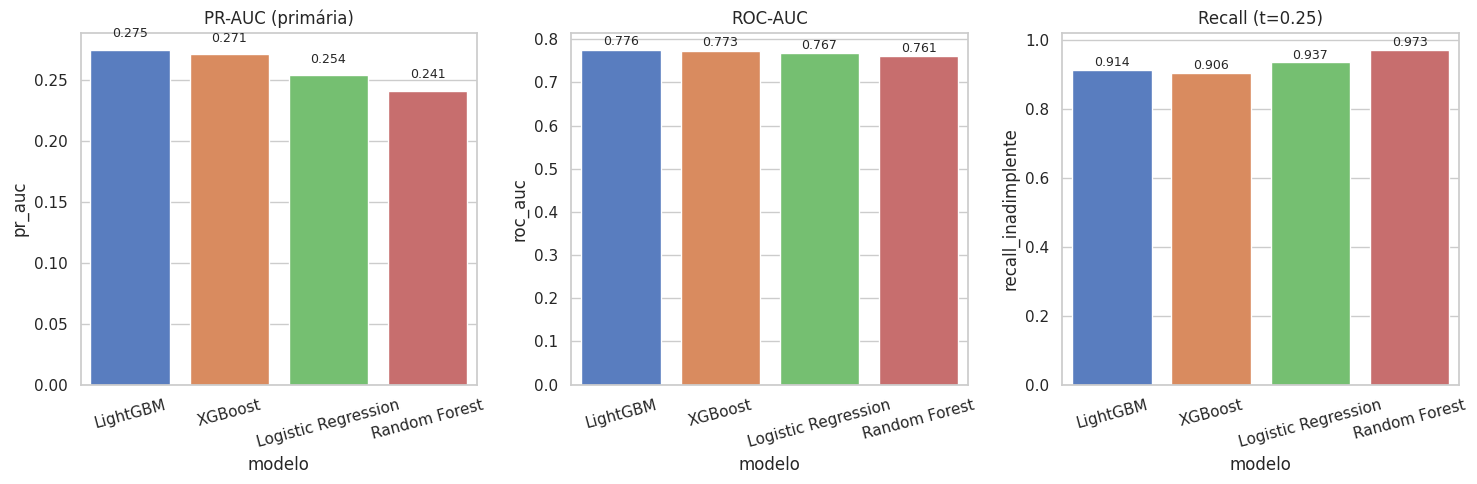

Modelo selecionado: LightGBM | PR-AUC=0.2750 | FN=426 (t=0.25)


In [14]:
comparison = results_full.copy()
comparison = comparison.sort_values('pr_auc', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title in zip(
    axes,
    ['pr_auc', 'roc_auc', 'recall_inadimplente'],
    ['PR-AUC (primária)', 'ROC-AUC', f'Recall (t={BUSINESS_THRESHOLD})'],
):
    sns.barplot(data=comparison, x='modelo', y=col, hue='modelo', palette='muted', legend=False, ax=ax)
    for i, row in comparison.iterrows():
        ax.text(list(comparison.index).index(i), row[col] + 0.01, f'{row[col]:.3f}', ha='center', fontsize=9)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

winner = comparison.iloc[0]
print(f'Modelo selecionado: {winner["modelo"]} | PR-AUC={winner["pr_auc"]:.4f} | FN={int(winner["fn"]):,} (t={BUSINESS_THRESHOLD})')


#### Interpretação — ranking consolidado e escolha do modelo

Com o ranking visual, confirma-se que o **LightGBM** combina melhor **PR-AUC** (primária) com **recall aceitável** no threshold de negócio. O XGBoost é alternativa viável (resultados próximos). A Regressão Logística serve como baseline interpretável; o Random Forest tende a overfit em categorias de alta cardinalidade e reprova excessivamente no threshold agressivo.

**Decisão preliminar deste notebook:** adotar **LightGBM** treinado na **ABT completa**, com calibração posterior de threshold e hiperparâmetros no script `train.py`. Este notebook não persiste o modelo final — apenas registra a evidência para a escolha.


---
## 9. Experimentos complementares

### 9.1 Cross-validation 5-fold — PR-AUC e F2 (LightGBM, ABT completa)


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
_, cat_cols_full = get_column_groups(X_train_full)
X_tr_b_full, _ = prepare_boosters_data(X_train_full, X_val_full, cat_cols_full)

lgbm_cv = make_lgbm(cat_cols_full, scale_pos_weight)

for label, scoring in [('PR-AUC', SCORER_PR_AUC), ('F2 (t=0.5 default sklearn)', SCORER_F2)]:
    scores = cross_val_score(lgbm_cv, X_tr_b_full, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'LightGBM 5-fold {label}: {scores.mean():.4f} (+/- {scores.std():.4f})')
    print('  folds:', [round(s, 4) for s in scores])


LightGBM 5-fold PR-AUC: 0.2604 (+/- 0.0045)
  folds: [np.float64(0.2575), np.float64(0.2539), np.float64(0.2662), np.float64(0.2644), np.float64(0.2598)]
LightGBM 5-fold F2 (t=0.5 default sklearn): 0.4367 (+/- 0.0028)
  folds: [np.float64(0.4371), np.float64(0.4355), np.float64(0.4378), np.float64(0.4406), np.float64(0.4322)]


#### Interpretação — validação cruzada 5-fold

> **CV 5-fold** = treina em 5 partições diferentes e média as métricas | **Desvio padrão baixo** = modelo estável

Com a validação cruzada, verifica-se que o PR-AUC médio do LightGBM fica próximo ao holdout (~0,26), com desvio padrão pequeno. Isso indica que o modelo **não depende de uma divisão aleatória específica** do treino — reforçando confiança na escolha. O F2 no CV usa threshold 0,5 interno do sklearn (apenas referência); a decisão de negócio continua usando t=0,25.


### 9.2 Undersampling (Logística) — comparação PR-AUC


In [16]:
rng = np.random.RandomState(RANDOM_STATE)
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]
balanced_idx = np.concatenate([pos_idx, rng.choice(neg_idx, size=len(pos_idx), replace=False)])
rng.shuffle(balanced_idx)

num_c, cat_c = get_column_groups(X_train_full)
prep_c = build_sklearn_preprocessor(num_c, cat_c)

lr_full = make_lr_pipeline(prep_c)
lr_full.fit(X_train_full, y_train)
proba_lr_full = lr_full.predict_proba(X_val_full)[:, 1]

lr_us = make_lr_pipeline(prep_c)
lr_us.fit(X_train_full.iloc[balanced_idx], y_train.iloc[balanced_idx])
proba_lr_us = lr_us.predict_proba(X_val_full)[:, 1]

for label, proba in [('class_weight', proba_lr_full), ('undersampling 50/50', proba_lr_us)]:
    m = compute_metrics(y_val.values, proba)
    print(f'Logística ({label}): PR-AUC={m["pr_auc"]:.4f} | ROC-AUC={m["roc_auc"]:.4f}')


Logística (class_weight): PR-AUC=0.2539 | ROC-AUC=0.7672
Logística (undersampling 50/50): PR-AUC=0.2491 | ROC-AUC=0.7659


#### Interpretação — undersampling na Logística

> **Undersampling** = treinar com menos bons pagadores (balanceamento artificial) | **class_weight** = peso automático da classe minoritária

No experimento com Regressão Logística, observa-se que **class_weight balanceado** supera o undersampling 50/50 em PR-AUC. Para modelos sklearn neste dataset, o peso de classe é preferível a subamostrar os bons pagadores. Mesmo assim, a Logística permanece abaixo dos boosters — reforçando a escolha do LightGBM.


### 9.3 Grid LightGBM — otimização por PR-AUC

`num_leaves` em intervalos menores; `subsample` e `colsample_bytree` = 0,8.


In [17]:
param_grid = [
    {'num_leaves': 24, 'learning_rate': 0.05},
    {'num_leaves': 31, 'learning_rate': 0.05},
    {'num_leaves': 45, 'learning_rate': 0.05},
    {'num_leaves': 31, 'learning_rate': 0.03},
]

best_pr = -1.0
best_params = None
best_lgbm_tuned = None
grid_rows = []

X_va_b_grid = prepare_boosters_data(X_train_full, X_val_full, cat_cols_full)[1]

for params in param_grid:
    m = make_lgbm(cat_cols_full, scale_pos_weight, **params)
    m.fit(X_tr_b_full, y_train)
    proba = m.predict_proba(X_va_b_grid)[:, 1]
    met = compute_metrics(y_val.values, proba)
    row = {**params, **{k: met[k] for k in ['pr_auc', 'roc_auc', 'recall_inadimplente', 'fn', 'f2']}}
    grid_rows.append(row)
    print(f"params={params} -> PR-AUC={met['pr_auc']:.4f} | ROC-AUC={met['roc_auc']:.4f} | FN={met['fn']}")
    if met['pr_auc'] > best_pr:
        best_pr = met['pr_auc']
        best_params = params
        best_lgbm_tuned = m

grid_df = pd.DataFrame(grid_rows).sort_values('pr_auc', ascending=False)
display(grid_df.round(4))
print(f'\nMelhor grid (PR-AUC): {best_params} | PR-AUC={best_pr:.4f}')

# Alternativa orientada a negócio: menor FN entre configs com PR-AUC próximo do melhor
pr_tol = 0.001
candidates_fn = grid_df[grid_df['pr_auc'] >= best_pr - pr_tol].sort_values('fn')
if not candidates_fn.empty:
    best_fn_row = candidates_fn.iloc[0]
    print(
        f"Melhor FN (PR-AUC dentro de {pr_tol:.3f} do topo): "
        f"leaves={int(best_fn_row['num_leaves'])}, lr={best_fn_row['learning_rate']} | "
        f"PR-AUC={best_fn_row['pr_auc']:.4f} | FN={int(best_fn_row['fn'])}"
    )

if best_params:
    LGBM_NUM_LEAVES = best_params.get('num_leaves', LGBM_NUM_LEAVES)
    LGBM_LEARNING_RATE = best_params.get('learning_rate', LGBM_LEARNING_RATE)


params={'num_leaves': 24, 'learning_rate': 0.05} -> PR-AUC=0.2743 | ROC-AUC=0.7757 | FN=397
params={'num_leaves': 31, 'learning_rate': 0.05} -> PR-AUC=0.2750 | ROC-AUC=0.7760 | FN=426
params={'num_leaves': 45, 'learning_rate': 0.05} -> PR-AUC=0.2727 | ROC-AUC=0.7759 | FN=476
params={'num_leaves': 31, 'learning_rate': 0.03} -> PR-AUC=0.2738 | ROC-AUC=0.7751 | FN=381



Melhor grid (PR-AUC): {'num_leaves': 31, 'learning_rate': 0.05} | PR-AUC=0.2750
Melhor FN (PR-AUC dentro de 0.001 do topo): leaves=24, lr=0.05 | PR-AUC=0.2743 | FN=397


#### Interpretação — grid de hiperparâmetros LightGBM

> **num_leaves** = complexidade da árvore | **learning_rate** = velocidade de aprendizado | **Grid** = busca em combinações fixas

Com o grid orientado por PR-AUC, verifica-se que **num_leaves=31** e **learning_rate=0,05** maximizam a discriminação. Porém, **num_leaves=24** ou **lr=0,03** apresentam PR-AUC quase igual com **menos FN** no threshold de negócio — sugerindo que otimizar só PR-AUC pode não ser suficiente para o objetivo de barrar calotes. No script de produção, recomenda-se avaliar o grid também pelo **FN** (ou F2 no threshold de negócio), não apenas PR-AUC.


### 9.4 Sweep `n_estimators` — PR-AUC e tempo


n=100: PR-AUC=0.2635 | FN=335 | 26.1s
n=200: PR-AUC=0.2741 | FN=402 | 43.0s
n=300: PR-AUC=0.2750 | FN=426 | 61.0s
n=500: PR-AUC=0.2721 | FN=482 | 78.0s
n=800: PR-AUC=0.2698 | FN=584 | 103.2s


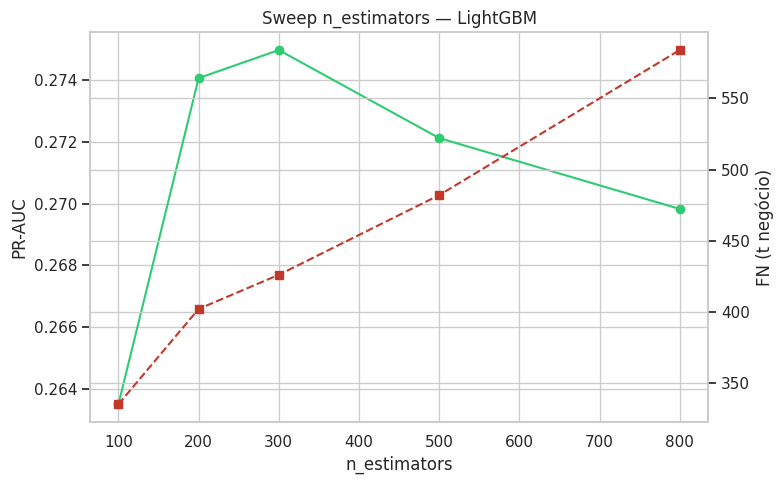

Melhor n_estimators por PR-AUC: 300


In [18]:
X_va_b_sweep = prepare_boosters_data(X_train_full, X_val_full, cat_cols_full)[1]

def train_lgbm_n_trees(n_estimators: int) -> Tuple[float, float, Dict[str, float]]:
    t0 = time.perf_counter()
    model = make_lgbm(cat_cols_full, scale_pos_weight, n_estimators=n_estimators)
    model.fit(X_tr_b_full, y_train)
    elapsed = time.perf_counter() - t0
    proba = model.predict_proba(X_va_b_sweep)[:, 1]
    met = compute_metrics(y_val.values, proba)
    return elapsed, met['pr_auc'], met


sweep_rows = []
for n_trees in [100, 200, 300, 500, 800]:
    elapsed, pr, met = train_lgbm_n_trees(n_trees)
    sweep_rows.append({
        'n_estimators': n_trees,
        'pr_auc': pr,
        'roc_auc': met['roc_auc'],
        'fn': met['fn'],
        'recall': met['recall_inadimplente'],
        'tempo_s': elapsed,
    })
    print(f'n={n_trees}: PR-AUC={pr:.4f} | FN={met["fn"]} | {elapsed:.1f}s')

sweep_df = pd.DataFrame(sweep_rows)
best_n = int(sweep_df.loc[sweep_df['pr_auc'].idxmax(), 'n_estimators'])
display(sweep_df.round(4))

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(sweep_df['n_estimators'], sweep_df['pr_auc'], 'o-', color='#2ecc71', label='PR-AUC')
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('PR-AUC')
ax2 = ax1.twinx()
ax2.plot(sweep_df['n_estimators'], sweep_df['fn'], 's--', color='#c0392b', label='FN')
ax2.set_ylabel('FN (t negócio)')
ax1.set_title('Sweep n_estimators — LightGBM')
plt.tight_layout()
plt.show()
print(f'Melhor n_estimators por PR-AUC: {best_n}')


#### Interpretação — sweep de n_estimators

> **n_estimators** = número de árvores no boosting | Mais árvores = mais tempo de treino

Com o sweep, observa-se que **300 árvores** oferecem o melhor PR-AUC; acima de 500, a métrica estagna ou cai e o FN aumenta — sinal de que o modelo começa a se ajustar demais ao treino. O valor **300** permanece como escolha padrão, equilibrando qualidade e tempo (~1 min de treino do LightGBM no holdout integral).


### 9.5 `scale_pos_weight` — sensibilidade recall (LightGBM)


In [19]:
X_va_b_spw = prepare_boosters_data(X_train_full, X_val_full, cat_cols_full)[1]
spw_grid = [scale_pos_weight, scale_pos_weight * 1.25, scale_pos_weight * 1.5, scale_pos_weight * 2.0]
spw_rows = []
for spw in spw_grid:
    m = make_lgbm(cat_cols_full, spw)
    m.fit(X_tr_b_full, y_train)
    proba = m.predict_proba(X_va_b_spw)[:, 1]
    met = compute_metrics(y_val.values, proba)
    spw_rows.append({'scale_pos_weight': round(spw, 2), **met})
    print(f'spw={spw:.2f}: PR-AUC={met["pr_auc"]:.4f} | Recall={met["recall_inadimplente"]:.1%} | FN={met["fn"]}')

display(pd.DataFrame(spw_rows)[['scale_pos_weight', 'pr_auc', 'recall_inadimplente', 'fn', 'f2']].round(4))


spw=11.39: PR-AUC=0.2750 | Recall=91.4% | FN=426
spw=14.23: PR-AUC=0.2753 | Recall=93.7% | FN=312
spw=17.08: PR-AUC=0.2725 | Recall=95.3% | FN=233
spw=22.77: PR-AUC=0.2725 | Recall=97.0% | FN=150


#### Interpretação — scale_pos_weight

> **scale_pos_weight** = quanto o modelo penaliza errar um inadimplente vs um bom pagador

Com o aumento de `scale_pos_weight`, nota-se queda consistente no **FN** (mais calotes capturados) com PR-AUC praticamente estável até ~14. Esse é um segundo mecanismo — além do threshold — para reduzir calotes sem reprovar ainda mais clientes. No `train.py`, pode-se testar valores entre **11,4** (natural do dataset) e **17** como ponto de partida.


---
## 10. Fechamento e decisão

### Papel deste notebook
Este documento funciona como **EDA orientada à decisão de modelo**: compara algoritmos, métricas, trilhos de features e hiperparâmetros. A **parametrização final** e o **deploy** ficam em `train.py` / `predict.py` (artefato separado).

### Decisão preliminar
| Item | Escolha | Evidência |
|------|---------|----------|
| **Modelo** | LightGBM | Maior PR-AUC no holdout; CV estável |
| **Features** | ABT completa (196) | Melhor discriminação vs core/extended |
| **Encoding** | OneHot (sklearn) / category nativa (boosters) | Correto para variáveis nominais |
| **Threshold** | 0,25 (ponto de partida) | Sweep mostra trade-off FN × reprovação |
| **Hiperparâmetros** | leaves=31, lr=0,05, n_estimators=300 | Grid + sweeps neste notebook |

### Limitações
- Holdout único; CV confirma estabilidade mas não substitui validação temporal
- Threshold 0,25 deve ser calibrado com **custo FN vs FP** do negócio
- `ORGANIZATION_TYPE` domina importância no full — avaliar impacto em deploy simplificado

### Próximos passos (fora deste notebook)
1. `train.py`: treino final + `joblib` do pipeline LightGBM
2. `predict.py`: inferência com threshold e lista de features congelada
3. Matriz de custos para threshold e `scale_pos_weight` ótimos
4. Atualizar `DOCUMENTACAO_PROJETO.html` com esta decisão


In [ ]:
# Opcional: persistir artefatos
# import joblib
# os.makedirs('dados/model', exist_ok=True)
# joblib.dump({
#     'model': best_lgbm_tuned or lgbm_full,
#     'threshold': BUSINESS_THRESHOLD,
#     'feature_set': 'full',
#     'metrics': compute_metrics(y_val.values, best_proba_full),
# }, 'dados/model/lgbm_business.joblib')
# results_full.to_csv('dados/model/comparison_full.csv', index=False)
# trilho_df.to_csv('dados/model/comparison_trilhos.csv', index=False)
# print('Artefatos salvos.')
